# Import Data + Preprocessing


In [3]:
#import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
import re
import math
from collections import Counter, defaultdict
%matplotlib inline
import random
import itertools
from sentence_transformers import SentenceTransformer, util

In [4]:
import gdown
import pandas as pd

file_id = "1kSQIo1kkDb53Mg4hbBehsEk57u9mjzkF"
url = f"https://drive.google.com/uc?id={file_id}"

df = pd.read_csv(url)
print(df.shape)
df.head()

(45466, 24)


C:\Users\Administrator\AppData\Local\Temp\ipykernel_14000\2522543376.py:7: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [5]:
#sắp xếp lại thứ tự các cột

new_order = [
    'id', 'imdb_id', 'title', 'original_title', 'release_date', 'runtime',
    'genres', 'tagline', 'overview', 'budget', 'revenue', 'production_companies',
    'production_countries', 'popularity', 'vote_average', 'vote_count',
    'original_language', 'spoken_languages', 'status', 'adult', 'video',
    'homepage', 'poster_path', 'belongs_to_collection'
]

#reindex lại DataFrame theo thứ tự mới
df = df[new_order]

#check lại
print(df.head())

      id    imdb_id                        title               original_title  \
0    862  tt0114709                    Toy Story                    Toy Story   
1   8844  tt0113497                      Jumanji                      Jumanji   
2  15602  tt0113228             Grumpier Old Men             Grumpier Old Men   
3  31357  tt0114885            Waiting to Exhale            Waiting to Exhale   
4  11862  tt0113041  Father of the Bride Part II  Father of the Bride Part II   

  release_date  runtime                                             genres  \
0   1995-10-30     81.0  [{'id': 16, 'name': 'Animation'}, {'id': 35, '...   
1   1995-12-15    104.0  [{'id': 12, 'name': 'Adventure'}, {'id': 14, '...   
2   1995-12-22    101.0  [{'id': 10749, 'name': 'Romance'}, {'id': 35, ...   
3   1995-12-22    127.0  [{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...   
4   1995-02-10    106.0                     [{'id': 35, 'name': 'Comedy'}]   

                                            

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     45466 non-null  object 
 1   imdb_id                45449 non-null  object 
 2   title                  45460 non-null  object 
 3   original_title         45466 non-null  object 
 4   release_date           45379 non-null  object 
 5   runtime                45203 non-null  float64
 6   genres                 45466 non-null  object 
 7   tagline                20412 non-null  object 
 8   overview               44512 non-null  object 
 9   budget                 45466 non-null  object 
 10  revenue                45460 non-null  float64
 11  production_companies   45463 non-null  object 
 12  production_countries   45463 non-null  object 
 13  popularity             45461 non-null  object 
 14  vote_average           45460 non-null  float64
 15  vo

In [7]:
df.shape

(45466, 24)

In [8]:
print(df.dtypes)

id                        object
imdb_id                   object
title                     object
original_title            object
release_date              object
runtime                  float64
genres                    object
tagline                   object
overview                  object
budget                    object
revenue                  float64
production_companies      object
production_countries      object
popularity                object
vote_average             float64
vote_count               float64
original_language         object
spoken_languages          object
status                    object
adult                     object
video                     object
homepage                  object
poster_path               object
belongs_to_collection     object
dtype: object


In [9]:
#check duplicate

total_duplicates = df.duplicated().sum()
print(f"Số dòng bị trùng lặp hoàn toàn: {total_duplicates}")

#xóa dup, chỉ giữ lại dòng đầu tiên, đè trực tiếp lên df cũ (inplace=True)
df.drop_duplicates(subset=['id'], keep='first', inplace=True)

# Kiểm tra lại số lượng dòng sau khi xóa
print(df.shape)

Số dòng bị trùng lặp hoàn toàn: 13
(45436, 24)


In [10]:
# thống kê Min, Max, Mean, Median của các cột số
print(df[['runtime', 'budget', 'revenue', 'vote_average']].describe())

# min dính 0 nhiều, max dính số quá dài (1256 phút ~ 21 tiếng), median hợp lý (1 fim ~ 1h35')
# min, 25%, 50%, 75% revenue đều bằng 0 -> thiếu dữ liệu
# vote average min = 0 -> chưa ai xem hoặc k có vote

           runtime       revenue  vote_average
count  45173.00000  4.543000e+04  45430.000000
mean      94.12430  1.121288e+07      5.618329
std       38.41554  6.435213e+07      1.924139
min        0.00000  0.000000e+00      0.000000
25%       85.00000  0.000000e+00      5.000000
50%       95.00000  0.000000e+00      6.000000
75%      107.00000  0.000000e+00      6.800000
max     1256.00000  2.787965e+09     10.000000


In [11]:
# fix các lỗi trên

# Thay thế số 0 bằng NaN cho các cột bị lỗi
df['runtime'] = df['runtime'].replace(0, np.nan)
df['revenue'] = df['revenue'].replace(0, np.nan)

# Riêng vote_average bằng 0 nghĩa là "chưa có vote", lọc bỏ khi phân tích điểm số

In [12]:
# Xem thử phim nào dài 21 tiếng
print(df[df['runtime'] > 300][['title', 'runtime']])

                               title  runtime
6747                           Shoah    566.0
7415       Tinker Tailor Soldier Spy    320.0
7420               The Best of Youth    366.0
7933                      The Deluge    315.0
8635                   War and Peace    422.0
...                              ...      ...
44176                      The Idiot    550.0
44464  The Guyver: Bio-Booster Armor    360.0
44721                    The Keepers    432.0
44758                      Hollywood    780.0
45462            Century of Birthing    360.0

[108 rows x 2 columns]


In [13]:
# Lọc ra chính xác bộ phim có thời lượng dài nhất
longest_movie = df[df['runtime'] == df['runtime'].max()]
print(longest_movie[['title', 'runtime', 'release_date']])

            title  runtime release_date
24178  Centennial   1256.0   1978-10-01


In [14]:
# Xem số lượng dòng trước khi lọc
print(f"Số lượng phim ban đầu: {df.shape[0]}")

# Giữ lại phim có thời lượng từ 45 phút trở lên (loại bỏ phim ngắn, phim lỗi 0 phút)
# Giữ lại phim có thời lượng từ 300 phút trở xuống (loại bỏ 108 phim siêu dài dính outlier)
df_clean = df[(df['runtime'] >= 45) & (df['runtime'] <= 300)].copy()

# Reset lại index của DataFrame
df_clean = df_clean.reset_index(drop=True)

# Kiểm tra lại sau khi lọc
print(f"Số lượng phim sau khi dọn dẹp: {df_clean.shape[0]}")
print(f"Đã loại bỏ được: {df.shape[0] - df_clean.shape[0]} bộ phim lỗi thời lượng.")

# Check lại min, max của dataframe mới
print("\nBảng thống kê thời lượng mới:")
print(df_clean['runtime'].describe())

Số lượng phim ban đầu: 45436
Số lượng phim sau khi dọn dẹp: 41900
Đã loại bỏ được: 3536 bộ phim lỗi thời lượng.

Bảng thống kê thời lượng mới:
count    41900.000000
mean        99.595967
std         22.959280
min         45.000000
25%         88.000000
50%         96.000000
75%        108.000000
max        300.000000
Name: runtime, dtype: float64


In [15]:
# Check status fim
print(df['status'].unique())

# check số lượng fim trước khi lọc status
print(f"Số lượng phim trước khi lọc status: {df_clean.shape[0]}")

# Chỉ giữ lại những dòng có status chính xác là 'Released'
df_clean = df_clean[df_clean['status'] == 'Released'].copy()

# reset_index sau khi lọc để tránh lệch ma trận Embedding của BERT
df_clean = df_clean.reset_index(drop=True)

# Kiểm tra lại số lượng phim sau khi lọc
print(f"Số lượng phim sau khi dọn dẹp status: {df_clean.shape[0]}")
print(f"Mảng các giá trị độc nhất bây giờ: {df_clean['status'].unique()}")

['Released' nan 'Rumored' 'Post Production' 'In Production' 'Planned'
 'Canceled']
Số lượng phim trước khi lọc status: 41900
Số lượng phim sau khi dọn dẹp status: 41542
Mảng các giá trị độc nhất bây giờ: ['Released']


In [16]:
# vì genres đang là 1 list nên cần trải ra + clean
import ast

# Hàm giải mã chuỗi và trích xuất chỉ lấy tên + thể loại
def extract_genres(genres_str):
    # Nếu dòng Null/NaN -> trả về chuỗi trống
    if pd.isna(genres_str) or genres_str == "":
        return ""

    try:
        # ast.literal_eval biến chuỗi "[{'id': 16, 'name': 'Animation'}]" thành list
        genres_list = ast.literal_eval(genres_str)

        # Lấy giá trị của key 'name' trong từng dictionary và nối lại bằng dấu phẩy
        names = [genre['name'] for genre in genres_list]
        return ", ".join(names)
    except:
        # Phòng trường hợp dòng nào đó dính lỗi định dạng đặc biệt
        return ""

# 2. Áp dụng hàm lên cột genres của df_clean
df_clean['genres'] = df_clean['genres'].apply(extract_genres)

# 3. Xem thử thành quả sau khi dọn dẹp sạch cột genres
print("Kiểu dữ liệu mới của ô đầu tiên:", type(df_clean['genres'].iloc[0]))
print("\nXem thử vài dòng dữ liệu genres sau khi làm sạch:")
print(df_clean[['title', 'genres']].head())

Kiểu dữ liệu mới của ô đầu tiên: <class 'str'>

Xem thử vài dòng dữ liệu genres sau khi làm sạch:
                         title                      genres
0                    Toy Story   Animation, Comedy, Family
1                      Jumanji  Adventure, Fantasy, Family
2             Grumpier Old Men             Romance, Comedy
3            Waiting to Exhale      Comedy, Drama, Romance
4  Father of the Bride Part II                      Comedy


In [17]:
# check overview fim (mô tả fim)
df_clean['overview'] = df_clean['overview'].fillna('')

# Xóa các câu text hệ thống tự điền khi thiếu mô tả -> chuyển về chữ thường
garbage_phrases = [
    'no overview found',
    'no overview available',
    'no plot text',
    'no plot available'
]

# Hàm dọn rác text mô tả
def clean_overview_text(text):
    if text.strip().lower() in garbage_phrases:
        return ""
    return text

df_clean['overview'] = df_clean['overview'].apply(clean_overview_text)

# check thử
empty_overviews = (df_clean['overview'] == "").sum()
print(f"Số lượng phim không có mô tả (đã đưa về chuỗi trống): {empty_overviews}")

Số lượng phim không có mô tả (đã đưa về chuỗi trống): 274


In [18]:
# export file data đã clean
df_clean.to_csv("movie_dataset_cleaned.csv", index=False, encoding="utf-8-sig")

# Feature Extraction

In [19]:
# Các cột được giữ lại và dùng cho mô hình
selected_features = [
    'id',
    'title',
    'genres',
    'overview',
    'release_date',
    'runtime',
    'popularity',
    'vote_average',
    'production_companies',
]

# Trích xuất DataFrame mới chỉ giữ lại các cột trên
df_final = df_clean[selected_features].copy()

# Add release_year to df_final
df_final['release_year'] = pd.to_datetime(df_final['release_date'], errors='coerce').dt.year

# Kiểm tra lại hình dạng của dữ liệu mới
print("Kích thước dataset sau khi chọn lọc feature:", df_final.shape)
print("\n5 dòng dữ liệu mẫu cuối cùng sẵn sàng cho các bước sau:")
print(df_final.head())

Kích thước dataset sau khi chọn lọc feature: (41542, 10)

5 dòng dữ liệu mẫu cuối cùng sẵn sàng cho các bước sau:
      id                        title                      genres  \
0    862                    Toy Story   Animation, Comedy, Family   
1   8844                      Jumanji  Adventure, Fantasy, Family   
2  15602             Grumpier Old Men             Romance, Comedy   
3  31357            Waiting to Exhale      Comedy, Drama, Romance   
4  11862  Father of the Bride Part II                      Comedy   

                                            overview release_date  runtime  \
0  Led by Woody, Andy's toys live happily in his ...   1995-10-30     81.0   
1  When siblings Judy and Peter discover an encha...   1995-12-15    104.0   
2  A family wedding reignites the ancient feud be...   1995-12-22    101.0   
3  Cheated on, mistreated and stepped on, the wom...   1995-12-22    127.0   
4  Just when George Banks has recovered from his ...   1995-02-10    106.0   

  

## Gộp các trường thông tin lại

Vì BERT chỉ nhận vào 1 chuỗi văn bản duy nhất cho mỗi đối tượng (input), không thể nhận một lúc 3-4 cột riêng biệt

Tạo một vector không gian duy nhất (single vector space) -> 1 vector (384 chiều) đại diện cho đúng bộ fim, khi user muốn tìm fim tương tự -> so sánh vector fim A với fim B

In [20]:
from sentence_transformers import SentenceTransformer
import torch

# 1. Gộp các thông tin từ Feature Selection
df_final['movie_content'] = (
    "Tên phim: " + df_final['title'].fillna('') +
    " . Thể loại: " + df_final['genres'].fillna('') +
    " . Nội dung: " + df_final['overview'].fillna('') +
    " . Công ty sản xuất: " + df_final['production_companies'].fillna('').astype(str)
)

print("--- KIỂM TRA INPUT SAU KHI GỘP FEATURE ---")
print(df_final['movie_content'].iloc[0])
print("-" * 50)

--- KIỂM TRA INPUT SAU KHI GỘP FEATURE ---
Tên phim: Toy Story . Thể loại: Animation, Comedy, Family . Nội dung: Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circumstances separate Buzz and Woody from their owner, the duo eventually learns to put aside their differences. . Công ty sản xuất: [{'name': 'Pixar Animation Studios', 'id': 3}]
--------------------------------------------------


# Visualization của content based

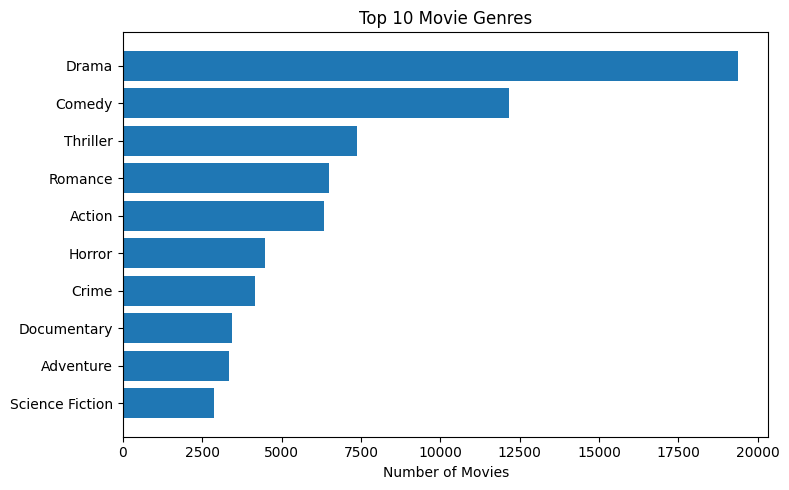

In [17]:
# phân bổ thể loại fim
import matplotlib.pyplot as plt

genres = (
    df_final["genres"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip())

top_genres = genres.value_counts().head(10)

plt.figure(figsize=(8,5))
plt.barh(top_genres.index[::-1], top_genres.values[::-1])

plt.xlabel("Number of Movies")
plt.title("Top 10 Movie Genres")

plt.tight_layout()
plt.show()

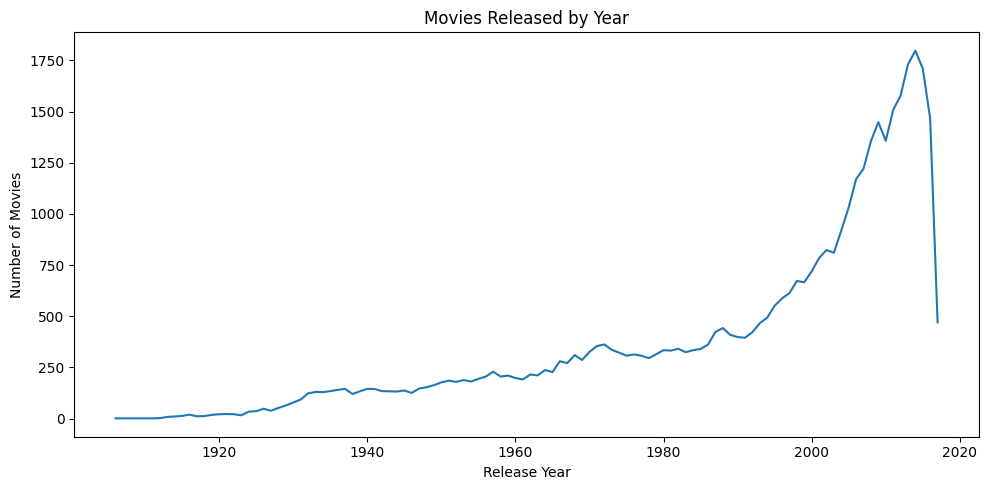

In [ ]:
# số lượng fim theo năm phát hành
df_clean["release_year"] = pd.to_datetime(
    df_clean["release_date"],
    errors="coerce"
).dt.year

year_counts = (df_clean["release_year"].value_counts().sort_index())

plt.figure(figsize=(10,5))

plt.plot(year_counts.index, year_counts.values)

plt.xlabel("Release Year")
plt.ylabel("Number of Movies")
plt.title("Movies Released by Year")

plt.tight_layout()
plt.show()

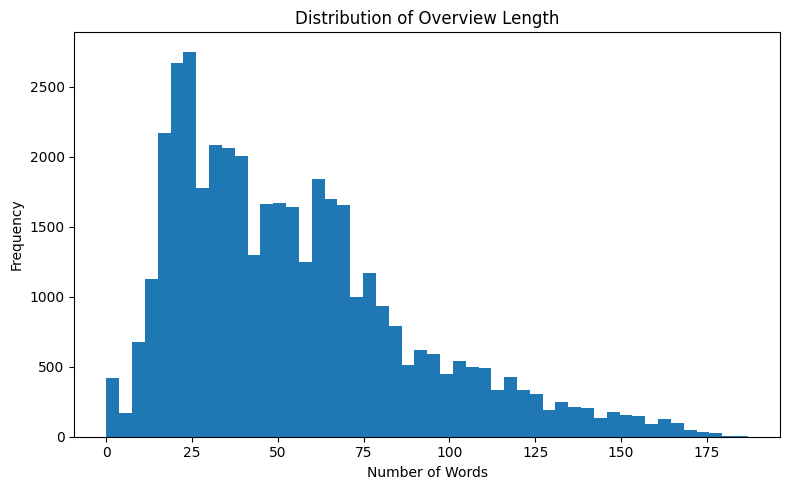

In [ ]:
# độ dài giới thiệu fim
df_clean["overview_length"] = (
    df_clean["overview"]
    .fillna("")
    .apply(lambda x: len(x.split())))

plt.figure(figsize=(8,5))

plt.hist(df_clean["overview_length"],bins=50)

plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.title("Distribution of Overview Length")

plt.tight_layout()
plt.show()

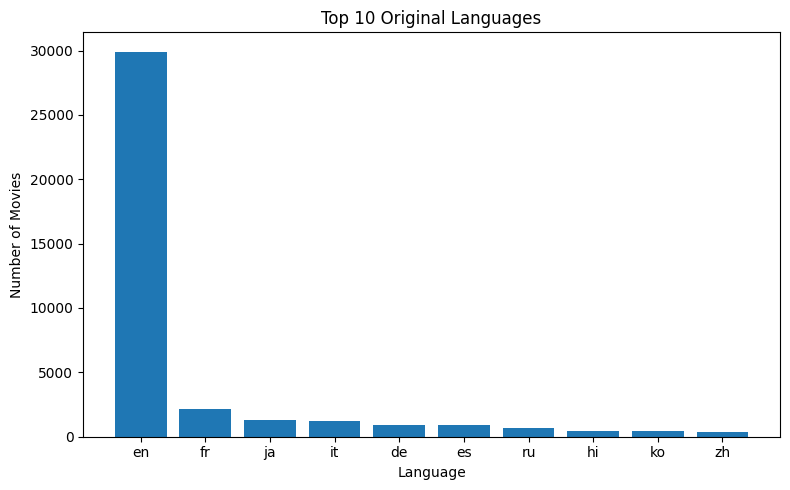

In [ ]:
# top 10 ngôn ngữ phổ biến
top_lang = (
    df_clean["original_language"]
    .value_counts()
    .head(10))

plt.figure(figsize=(8,5))

plt.bar(top_lang.index, top_lang.values)

plt.xlabel("Language")
plt.ylabel("Number of Movies")
plt.title("Top 10 Original Languages")

plt.tight_layout()
plt.show()

In [ ]:
# Chuyển về datetime
df_clean['release_date'] = pd.to_datetime(
    df_clean['release_date'],
    errors='coerce'
)

# Tách năm
df_clean['release_year'] = df_clean['release_date'].dt.year

# Kiểm tra
print(df_clean['release_year'].head())

0    1995.0
1    1995.0
2    1995.0
3    1995.0
4    1995.0
Name: release_year, dtype: float64


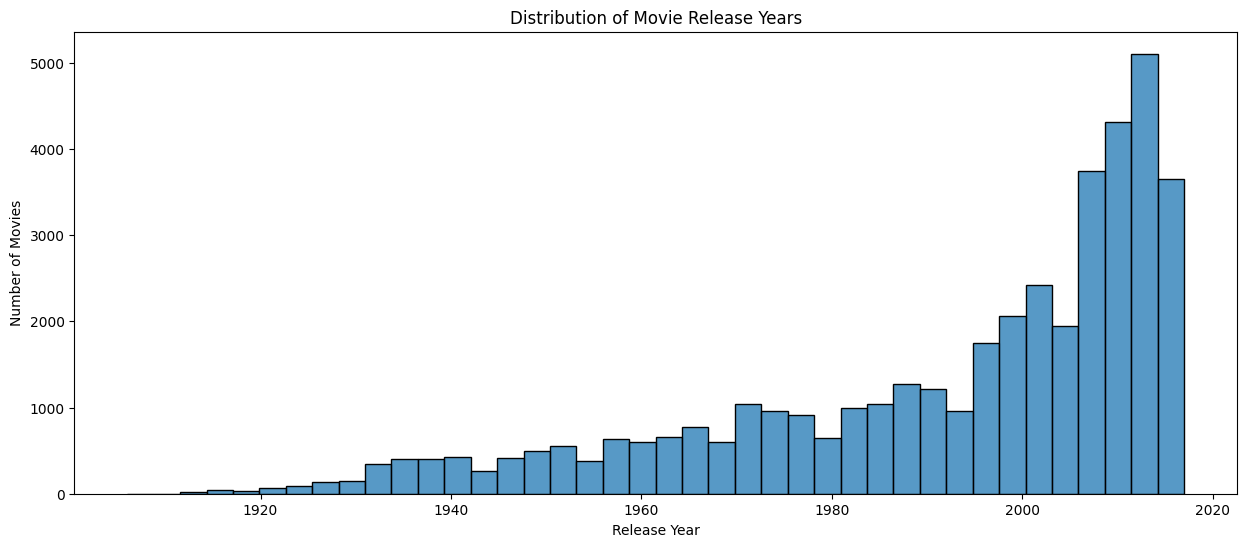

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

sns.histplot(
    data=df_clean,
    x='release_year',
    bins=40
)

plt.title('Distribution of Movie Release Years')
plt.xlabel('Release Year')
plt.ylabel('Number of Movies')

plt.show()

# Applying BERT

## BERT Preprocessing (Tokenize, Embedding, etc)

- Model dùng: all-MiniLM-L6-v2 (pretrained)

- Vì dùng model trên nên preprocessing không quá phức tạp, chỉ cần gọi hàm model.encode(). Hàm tự động chạy ngầm các bước sau:

- Tokenize: Tách câu -> các từ đơn ->  chuyển văn bản thành các ID số mà BERT hiểu.

- Padding & Truncation: Tự cắt ngắn nếu văn bản dài quá 256/512 tokens hoặc thêm chuỗi trống nếu quá ngắn để đưa về độ dài bằng nhau.

- Forward Pass: Đưa qua các tầng Transformer để lấy kết quả nhúng thô.

- Pooling (Trích xuất Embedding cuối cùng): Gom các vector của từng từ lại thành một vector duy nhất đại diện cho cả bộ phim (thường dùng Mean Pooling).

In [21]:
# import BERT model
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

In [22]:
# Kiểm tra độ dài tối đa mà mô hình hỗ trợ xử lý cho một chuỗi text
print("Độ dài chuỗi tối đa mô hình hỗ trợ (max_seq_length):", model.get_max_seq_length())

Độ dài chuỗi tối đa mô hình hỗ trợ (max_seq_length): 256


all-miniLM-L6-v2 là Sentence-BERT bi encoder, phiên bản nhẹ hơn của BERT, được train bằng knowledge distillation, ít layer hơn nên train nhanh hơn.

- L6 = 6 transformer layers
- BERT-base = 12 layers
-> nhanh hơn

- v2: được fine-tune cho semantic similarity + retrieval, tối ưu cosine similarity

Input đưa vào là 1 câu hoặc 1 đoạn text, ở đây là tên phim. Output là 1 vector embedding (384 dims) trong khi BERT-base là 768 dims.
Các câu (tìm kiếm của user và tên phim tương ứng) sẽ có vector gần nhau.

Ví dụ:
Query 1 = "Avengers: Endgame"
Query 2 = "Avengers Infinity War"

-> Sau khi encode, vector của hai phim sẽ gần nhau vì chúng thuộc cùng series, có nội dung và nhân vật liên quan. Do đó cosine similarity giữa hai vector sẽ cao.

In [24]:
# Tokenize + embedding + pooling ngầm
print("Đang thực hiện BERT preprocessing và áp dụng Bi-encoder...")

movie_embeddings = model.encode(
    df_final['movie_content'].tolist(),
    show_progress_bar=True,
    convert_to_tensor=True
)

print("Quá trình Preprocessing và  áp dụng Bi-encoder hoàn tất!")

Đang thực hiện BERT preprocessing và áp dụng Bi-encoder...


Batches:   0%|          | 0/1299 [00:00<?, ?it/s]

Quá trình Preprocessing và  áp dụng Bi-encoder hoàn tất!


In [25]:
# Check hình dáng của ma trận vector
print("Kích thước ma trận embedding:", movie_embeddings.shape)

Kích thước ma trận embedding: torch.Size([41542, 384])


In [26]:
# Xem thử vector đại diện của bộ phim đầu tiên (Toy Story)
# Lấy dòng index 0, in ra 10 số đầu tiên trong tổng số 384 chiều của nó
print("10 giá trị đặc trưng đầu tiên của phim Toy Story:")
print(movie_embeddings[0][:10])

10 giá trị đặc trưng đầu tiên của phim Toy Story:
tensor([ 0.0064, -0.0487,  0.0924, -0.0750,  0.0265,  0.0470,  0.1575,  0.0040,
        -0.0150, -0.0239])


In [27]:
# Check nan/null trong vector
# Nếu movie_embeddings là PyTorch Tensor (mặc định khi dùng convert_to_tensor=True)
has_nan = torch.isnan(movie_embeddings).any().item()
print("Ma trận vector có bị dính lỗi NaN (mất dữ liệu) không?:", has_nan)

Ma trận vector có bị dính lỗi NaN (mất dữ liệu) không?: False


In [28]:
# Check thử BERT = 3 fim đầu tiên

from sentence_transformers import util

# Tính thử độ tương đồng giữa Toy Story (hoạt hình gia đình) vs Jumanji (phiêu lưu giả tưởng)
sim_0_1 = util.cos_sim(movie_embeddings[0], movie_embeddings[1]).item()

# Tính thử độ tương đồng giữa Toy Story với Grumpier Old Men (tình cảm người lớn)
sim_0_2 = util.cos_sim(movie_embeddings[0], movie_embeddings[2]).item()

print(f"Độ tương đồng giữa Toy Story và Jumanji: {sim_0_1:.4f}")
print(f"Độ tương đồng giữa Toy Story và Grumpier Old Men: {sim_0_2:.4f}")

Độ tương đồng giữa Toy Story và Jumanji: 0.5795
Độ tương đồng giữa Toy Story và Grumpier Old Men: 0.5543


In [29]:
# Chuẩn hóa (normalize)
import torch

# Chuẩn hóa L2 cho ma trận vector
# Sau khi chuẩn hóa, bình phương độ dài của mỗi vector phim sẽ bằng 1
movie_embeddings_norm = torch.nn.functional.normalize(movie_embeddings, p=2, dim=1)

print("Kích thước ma trận vector sau chuẩn hóa:", movie_embeddings_norm.shape)

Kích thước ma trận vector sau chuẩn hóa: torch.Size([41542, 384])


Chuẩn hóa L2 (L2 Normalization) là biến đổi một vector sao cho độ dài (norm) của vector bằng 1, nhưng vẫn giữ nguyên hướng của vector.

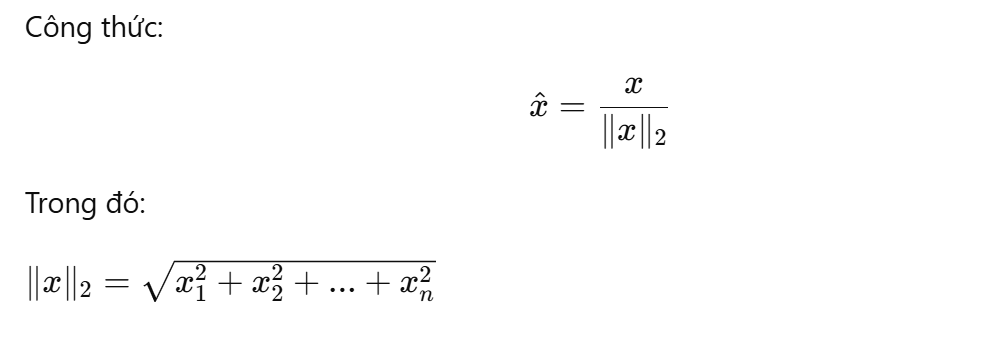

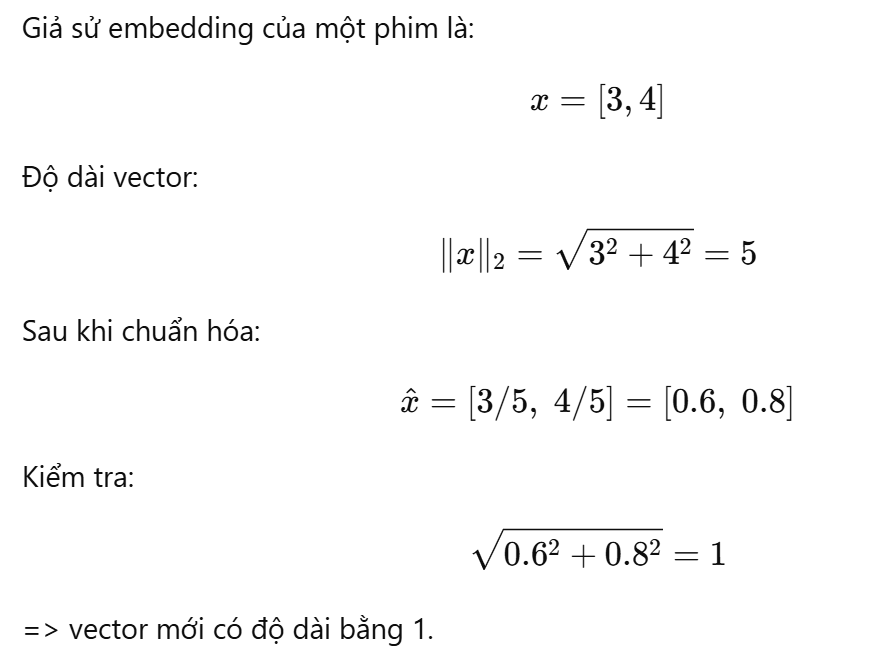

# Calculate cosine similarity

In [29]:
from sentence_transformers import util

def recommend_movies(movie_title, top_k=5):
    # Tìm index của bộ phim người dùng nhập vào trong df_final
    movie_title_clean = movie_title.strip().lower()
    matched_movies = df_final[df_final['title'].str.lower().str.contains(movie_title_clean)]

    if matched_movies.empty:
        print(f"Không tìm thấy phim '{movie_title}' trong hệ thống dữ liệu!")
        return None

    # Lấy index dòng đầu tiên tìm được
    idx = matched_movies.index[0]

    # 2. Lấy vector đặc trưng của bộ phim mục tiêu này
    target_embedding = movie_embeddings_norm[idx]

    # 3. Tính cosine similarity động
    # Tính độ tương đồng giữa 1 vector phim này với toàn bộ ma trận 41.542 vector phim kia
    cosine_scores = util.cos_sim(target_embedding, movie_embeddings_norm)[0]

    # 4. Candidate movie retrieval (lọc top-k)
    # Sắp xếp điểm số từ cao xuống thấp và lấy ra top_k + 1 phim (cộng 1 vì phim giống nhất là chính nó)
    top_results = torch.topk(cosine_scores, k=top_k + 1)

    # Lấy ra index và điểm số tương đồng thực tế
    top_indices = top_results.indices.cpu().numpy()
    top_scores = top_results.values.cpu().numpy()

    # Loại bỏ vị trí đầu tiên (vì index đầu tiên luôn là chính bộ phim đó với điểm Cosine = 1.0)
    recommended_indices = top_indices[1:]
    recommended_scores = top_scores[1:]

    # 5. Trích xuất kết quả xuất ra bảng
    recommendations = df_final.iloc[recommended_indices].copy()
    recommendations['similarity_score'] = recommended_scores

    print(f"Vì bạn đã xem phim: '{df_final.iloc[idx]['title']}'")
    print(f"Hệ thống gợi ý Top {top_k} bộ phim có nội dung tương đồng nhất sau đây:\n")

    # Hiển thị các trường thông tin quan trọng ra màn hình
    return recommendations[['title', 'genres', 'release_date', 'vote_average', 'similarity_score']]

In [ ]:
# test
movie_name = input("Nhập tên phim: ")

results = recommend_movies(movie_name, top_k=10)

if results is not None:
    print("\n===== DANH SÁCH PHIM ĐỀ XUẤT =====\n")

    for i, row in enumerate(results.itertuples(), start=1):
        print(f"{i}. {row.title}")
        print(f"   Thể loại: {row.genres}")
        print(f"   Năm phát hành: {row.release_date}")
        print(f"   Rating: {row.vote_average}")
        print(f"   Similarity: {row.similarity_score:.4f}")
        print("-" * 50)

##BERT Score

Mapping 2 file trước khi tính score

In [30]:
%pip install bert-score

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
from sklearn.model_selection import train_test_split

# đọc file
df_movies = pd.read_csv('movies.csv')
df_ratings = pd.read_csv('ratings.csv')
df_users = pd.read_csv("users.csv")

print("--- KIỂM TRA ĐỊNH DẠNG FILE RATINGS ---")
print(df_ratings.head())
print("-" * 50)

# kiểm tra tên cột
df_ratings.columns = ['user_id', 'movie_id', 'rating', 'timestamp']

# Loại bỏ các dòng thiếu dữ liệu nếu có
df_ratings = df_ratings.dropna().reset_index(drop=True)

--- KIỂM TRA ĐỊNH DẠNG FILE RATINGS ---
   UserID  MovieID  Rating  Timestamp
0       1     1193       5  978300760
1       1      661       3  978302109
2       1      914       3  978301968
3       1     3408       4  978300275
4       1     2355       5  978824291
--------------------------------------------------


In [32]:
df_ratings = pd.read_csv('ratings.csv')
df_ratings.columns = ['user_id', 'movie_id', 'rating', 'timestamp']

df_movies_ratings = pd.read_csv('movies.csv')
df_movies_ratings.columns = ['movie_id', 'title', 'genres'] # Đảm bảo đúng tên cột

# Ép kiểu và làm sạch cột tên phim của file movies_ratings
df_movies_ratings['title_clean'] = df_movies_ratings['title'].astype(str).str.lower().str.strip()
# Tên phim bên ratings có chứa năm dạng "(1995)" -> dùng regex xóa nó đi để đồng bộ với df_final
df_movies_ratings['title_clean'] = df_movies_ratings['title_clean'].str.replace(r'\s*\(\d{4}\)', '', regex=True)

# Làm sạch cột tên phim của bảng df_final (bảng dùng cho BERT)
df_final_copy = df_final.copy()
df_final_copy['title_clean'] = df_final_copy['title'].astype(str).str.lower().str.strip()
df_final_copy['id'] = df_final_copy['id'].astype(str).str.strip()

# Tìm mã ID của BERT dựa trên tên phim đã làm sạch
mapping_bridge = pd.merge(
    df_movies_ratings[['movie_id', 'title_clean']],
    df_final_copy[['id', 'title_clean']],
    on='title_clean',
    how='inner')

# Thay thế ID cũ trong ratings bằng ID mới đồng bộ với BERT
# Tạo bộ từ điển dịch thuật từ ID cũ sang ID mới của BERT
id_dict_mapping = dict(zip(mapping_bridge['movie_id'], mapping_bridge['id']))
df_ratings['movie_id'] = df_ratings['movie_id'].map(id_dict_mapping)

# Loại bỏ các dòng không mapping được
df_ratings_cleaned = df_ratings.dropna().reset_index(drop=True)

print("--- KIỂM TRA LẠI FILE RATINGS SAU KHI ĐỔI CHIẾN THUẬT MAPPING ---")
print(f"Số lượng dòng giữ lại được: {len(df_ratings_cleaned)}")
if not df_ratings_cleaned.empty:
    print(df_ratings_cleaned.head())
else:
    print("Vẫn bị trống!")

--- KIỂM TRA LẠI FILE RATINGS SAU KHI ĐỔI CHIẾN THUẬT MAPPING ---
Số lượng dòng giữ lại được: 712685
   user_id movie_id  rating  timestamp
0        1      510       5  978300760
1        1    10539       3  978302109
2        1    11113       3  978301968
3        1      462       4  978300275
4        1   271969       5  978302039


In [33]:
# Ratings gốc của MovieLens
df_ratings = pd.read_csv("ratings.csv")
df_ratings.columns = ["user_id", "movie_id", "rating", "timestamp"]

# Movies của MovieLens
df_movies = pd.read_csv("movies.csv")
df_movies.columns = ["movie_id", "title", "genres"]

# làm sạch title
# MovieLens
df_movies["title_clean"] = (
    df_movies["title"]
    .astype(str)
    .str.lower()
    .str.strip()
)

# Xóa năm (1995)
df_movies["title_clean"] = df_movies["title_clean"].str.replace(
    r"\s*\(\d{4}\)",
    "",
    regex=True
)

# TMDB/BERT
df_final_copy = df_final.copy()

df_final_copy["id"] = (
    df_final_copy["id"]
    .astype(str)
    .str.strip()
)

df_final_copy["title_clean"] = (
    df_final_copy["title"]
    .astype(str)
    .str.lower()
    .str.strip()
)

In [34]:
# tạo bảng mapping
mapping_bridge = pd.merge(
    df_movies[["movie_id", "title_clean"]],
    df_final_copy[["id", "title_clean"]],
    on="title_clean",
    how="inner"
)

print("Số dòng mapping ban đầu:", len(mapping_bridge))

Số dòng mapping ban đầu: 3098


In [35]:
# check dup
duplicate_count = mapping_bridge["movie_id"].duplicated().sum()

print("MovieLens movie_id bị map nhiều lần:", duplicate_count)

MovieLens movie_id bị map nhiều lần: 553


In [36]:
# sửa dup
mapping_bridge = (
    mapping_bridge
    .drop_duplicates(subset="movie_id", keep="first")
    .reset_index(drop=True)
)

print("Số movie mapping cuối cùng:", len(mapping_bridge))

Số movie mapping cuối cùng: 2545


In [37]:
# đổi movielens -> tmdb id
id_mapping = dict(
    zip(
        mapping_bridge["movie_id"],
        mapping_bridge["id"]
    )
)

df_ratings["movie_id"] = (
    df_ratings["movie_id"]
    .map(id_mapping)
)

In [38]:
# loại bỏ ratings k map dc
df_ratings_cleaned = (
    df_ratings
    .dropna(subset=["movie_id"])
    .reset_index(drop=True)
)

df_ratings_cleaned["movie_id"] = (
    df_ratings_cleaned["movie_id"]
    .astype(str)
)

In [39]:
# check kqa
print("===== KẾT QUẢ MAPPING =====")

print("Số rating ban đầu:", len(df_ratings))
print("Số rating giữ lại:", len(df_ratings_cleaned))

retention = (
    len(df_ratings_cleaned)
    / len(df_ratings)
    * 100
)

print(f"Tỷ lệ giữ lại: {retention:.2f}%")

print("\nVí dụ dữ liệu sau mapping:")
print(df_ratings_cleaned.head())

===== KẾT QUẢ MAPPING =====
Số rating ban đầu: 1000209
Số rating giữ lại: 712685
Tỷ lệ giữ lại: 71.25%

Ví dụ dữ liệu sau mapping:
   user_id movie_id  rating  timestamp
0        1      510       5  978300760
1        1    10539       3  978302109
2        1    11113       3  978301968
3        1      462       4  978300275
4        1      665       5  978302039


In [40]:
mapping_bridge.to_csv("movie_mapping.csv", index=False)
print("Đã lưu movie_mapping.csv")

Đã lưu movie_mapping.csv


## Lấy fim cuối user xem làm fim mồi

In [41]:
from sentence_transformers import util

def get_bert_top_k_recommendations(seed_movie_id, movie_embeddings, df_movies_cleaned, top_k=10):
    """
    Hàm lấy ra danh sách Top-K ID phim tương đồng nhất bằng BERT dựa trên 1 ID phim mồi
    """
    # 'id' trong bảng phim là string để so sánh chuẩn xác
    df_movies_cleaned = df_movies_cleaned.copy()
    df_movies_cleaned['id'] = df_movies_cleaned['id'].astype(str).str.strip()

    # Tìm xem movie_id này nằm ở dòng index số mấy trong ma trận BERT
    matched_indices = df_movies_cleaned[df_movies_cleaned['id'] == str(seed_movie_id).strip()].index

    # Nếu không tìm thấy phim này trong kho dữ liệu phim của BERT, bỏ qua
    if len(matched_indices) == 0:
        return []

    seed_idx = matched_indices[0]

    # Bốc vector của phim mồi ra
    target_embedding = movie_embeddings[seed_idx]

    # Tính điểm Cosine Similarity giữa phim mồi và toàn bộ kho phim
    cosine_scores = util.cos_sim(target_embedding, movie_embeddings)[0]

    # Lấy Top K+1 phim có điểm cao nhất
    top_results = torch.topk(cosine_scores, k=top_k + 1)
    top_indices = top_results.indices.cpu().numpy()[1:] # Bỏ phần tử đầu tiên (chính nó)

    # Chuyển đổi các chỉ số dòng (Index) này ngược lại thành ID phim thực tế ngoài đời để trả về
    predicted_movie_ids = df_movies_cleaned.iloc[top_indices]['id'].tolist()

    return predicted_movie_ids

In [42]:
#test
test_id = df_final['id'].iloc[0] # Using df_final['id'] as source
print(get_bert_top_k_recommendations(test_id, movie_embeddings, df_final, top_k=10)) # Using df_final here

['863', '10193', '15789', '56648', '15653', '11187', '13688', '38013', '223706', '15302']


In [43]:
# ID ở df_final là chuỗi text sạch
df_final['id'] = df_final['id'].astype(str).str.strip()

# ID ở file ratings cũng là chuỗi text sạch để so sánh
df_ratings['movie_id'] = df_ratings['movie_id'].astype(str).str.strip()

# Chỉ giữ lại những dòng ratings nào mà ID phim có xuất hiện trong bảng df_final
df_ratings_cleaned = df_ratings[df_ratings['movie_id'].isin(df_final['id'])].reset_index(drop=True)

print(f"Số lượng ratings ban đầu: {len(df_ratings)}")
print(f"Số lượng ratings sau khi lọc đồng bộ với df_final: {len(df_ratings_cleaned)}")

Số lượng ratings ban đầu: 1000209
Số lượng ratings sau khi lọc đồng bộ với df_final: 712685


Chia train + test theo leave 2 out

In [44]:
df_ratings_sorted = (
    df_ratings_cleaned
    .sort_values(["user_id", "timestamp"])
)

train_list = []
test_list = []

for user_id, group in df_ratings_sorted.groupby("user_id"):

    # bỏ user quá ít phim
    if len(group) < 3:
        continue

    train_list.append(group.iloc[:-2])

    test_list.append(group.iloc[-2:])

df_ratings_train = pd.concat(train_list)

df_ratings_test = pd.concat(test_list)

print("Train size:", len(df_ratings_train))
print("Test size:", len(df_ratings_test))

Train size: 700605
Test size: 12080


In [50]:
def calculate_bert_metrics_official(test_df, train_df, movie_embeddings, df_movies_cleaned, top_k=10):
    """
    Hàm tính toán chỉ số Benchmark Precision@K và Recall@K chính thức cho nhánh BERT.
    - Đã đồng bộ ép kiểu dữ liệu chuỗi (String) để đảm bảo không bị sót dữ liệu.
    """
    all_precisions = []
    all_recalls = []

    # 1. Đồng bộ ép kiểu ID trong bảng phim về dạng String chuẩn để tra cứu dòng (Index)
    df_movies_cleaned = df_movies_cleaned.copy()
    df_movies_cleaned['id'] = df_movies_cleaned['id'].astype(str).str.strip()

    # 2. Tìm danh sách các user có tương tác xuất hiện ở cả tập Train và tập Test
    common_users = set(test_df['user_id']).intersection(set(train_df['user_id']))

    print(f"Đang quét và tính toán Benchmark cho {len(common_users)} người dùng...")

    # Biến đếm để theo dõi tiến trình chạy
    count = 0

    for user in common_users:
        # Lấy đáp án thực tế: Những phim user thực sự xem/thích trong tập Test (Ép về String)
        actual_liked_movies = set(test_df[test_df['user_id'] == user]['movie_id'].astype(str).str.strip().tolist())

        # Nếu user không có đáp án ở tập test, bỏ qua
        if not actual_liked_movies:
            continue

        # Lấy phim mồi: Bộ phim cuối cùng user xem trong tập Train (Ép về String)
        user_train_history = train_df[train_df['user_id'] == user]
        if user_train_history.empty:
            continue
        seed_movie_id = str(user_train_history.iloc[-1]['movie_id']).strip()

        # 3. Gọi hàm BERT lấy danh sách Top-K phim tương đồng nhất
        predicted_movie_ids = get_bert_top_k_recommendations(seed_movie_id, movie_embeddings, df_movies_cleaned, top_k=top_k)
        predicted_movie_ids = [str(pid).strip() for pid in predicted_movie_ids]

        # Nếu hàm gợi ý trả về rỗng (không tìm thấy phim mồi trong kho)
        if not predicted_movie_ids:
            continue

        # 4. Đếm số phim đoán trúng (Giao giữa danh sách gợi ý và đáp án thực tế)
        hits = len(set(predicted_movie_ids).intersection(actual_liked_movies))

        # 5. Tính chỉ số Precision@K và Recall@K cho riêng user này
        precision_k = hits / top_k
        recall_k = hits / len(actual_liked_movies)

        all_precisions.append(precision_k)
        all_recalls.append(recall_k)

        # Cập nhật tiến trình in ra màn hình (cứ mỗi 500 user in 1 lần)
        count += 1
        if count % 500 == 0:
            print(f"   > Đã xử lý xong {count} / {len(common_users)} users...")

    # 6. Tính trung bình cộng (Mean) của toàn bộ hệ thống
    mean_precision = np.mean(all_precisions) if all_precisions else 0
    mean_recall = np.mean(all_recalls) if all_recalls else 0

    return mean_precision, mean_recall

bert_precision, bert_recall = calculate_bert_metrics_official(
    df_ratings_test,
    df_ratings_train,
    movie_embeddings,    # Ma trận vector của BERT
    df_final,            # Bảng chứa thông tin phim
    top_k=10
)

print("\n========================================================")
print("KẾT QUẢ BENCHMARK CHÍNH THỨC CỦA NHÁNH BERT Content-Based")
print(f"Precision@10: {bert_precision:.4f} ({bert_precision * 100:.2f}%)")
print(f"Recall@10:    {bert_recall:.4f} ({bert_recall * 100:.2f}%)")
print("============================================================")

Đang quét và tính toán Benchmark cho 6040 người dùng...
   > Đã xử lý xong 500 / 6040 users...
   > Đã xử lý xong 1000 / 6040 users...
   > Đã xử lý xong 1500 / 6040 users...
   > Đã xử lý xong 2000 / 6040 users...
   > Đã xử lý xong 2500 / 6040 users...
   > Đã xử lý xong 3000 / 6040 users...
   > Đã xử lý xong 3500 / 6040 users...
   > Đã xử lý xong 4000 / 6040 users...
   > Đã xử lý xong 4500 / 6040 users...
   > Đã xử lý xong 5000 / 6040 users...
   > Đã xử lý xong 5500 / 6040 users...
   > Đã xử lý xong 6000 / 6040 users...

KẾT QUẢ BENCHMARK CHÍNH THỨC CỦA NHÁNH BERT Content-Based
Precision@10: 0.0017 (0.17%)
Recall@10:    0.0084 (0.84%)


In [58]:
def calculate_bert_metrics_full(
    test_df,
    train_df,
    movie_embeddings,
    df_movies_cleaned,
    top_k=10):

    hit_rates = []
    average_precisions = []

    df_movies_cleaned = df_movies_cleaned.copy()
    df_movies_cleaned["id"] = (df_movies_cleaned["id"].astype(str).str.strip())

    common_users = set(test_df["user_id"]).intersection(set(train_df["user_id"]))

    print(f"Evaluating {len(common_users)} users...")

    for user in common_users:

        # Ground Truth
        actual_movies = set(test_df[test_df["user_id"] == user]["movie_id"]
            .astype(str)
            .str.strip()
            .tolist())

        if len(actual_movies) == 0:
            continue

        # Seed Movie
        user_train = train_df[
            train_df["user_id"] == user]

        if user_train.empty:
            continue

        seed_movie_id = str(user_train.iloc[-1]["movie_id"]).strip()

        # Top-K Recommendation
        predicted_movies = (
            get_bert_top_k_recommendations(
                seed_movie_id,
                movie_embeddings,
                df_movies_cleaned,
                top_k=top_k))

        predicted_movies = [str(mid).strip()for mid in predicted_movies]

        if len(predicted_movies) == 0:
            continue

        # Calculate hits
        hits = len(set(predicted_movies).intersection(actual_movies))

        # Hit Rate
        hit_rate = 1 if hits > 0 else 0

        hit_rates.append(hit_rate)


    hit_rate = (np.mean(hit_rates)if hit_rates else 0)

    map_k = (np.mean(average_precisions)if average_precisions else 0)

    return (
        hit_rate,
        map_k)

In [59]:
bert_hitrate,\
bert_map = calculate_bert_metrics_full(
    df_ratings_test,
    df_ratings_train,
    movie_embeddings,
    df_final,
    top_k=10)

print("\n========== BERT RESULTS ==========")
print(f"Hit Rate@10  : {bert_hitrate:.4f}")
print(f"MAP@10       : {bert_map:.4f}")

Evaluating 6040 users...

========== BERT RESULTS ==========
Hit Rate@10  : 0.0144
MAP@10       : 0.0000


- Hệ thống lấy 1 bộ fim làm mồi, sau đấy BERT đi tìm n bộ fim tương tự. Tuy nhiên, nếu thực tế user xem 10 bộ fim hành động nhưng bộ cuối cùng là fim hoạt hình thì BERT sẽ gợi ý tiếp 10 bộ fim hoạt hình khác.

-> Khi sang tập test, user quay lại xem tiếp fim hành động -> lệch hoàn toàn, điểm đánh giá bằng 0.

- BERT chỉ hiểu nội dung văn bản (nội dung/mô tả phim), không hiểu được hành vi số đông.

-> Hành vi xem của user có thể bị ảnh hưởng bởi tâm lý hoặc theo số đông, trend. Mô hình không có khả năng nắm bắt được điều này.

-> AIs nắm được nên mới hybird.

# Collaborative

In [46]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

movies  = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")
users   = pd.read_csv("users.csv")

print(ratings.head())
print(movies.head())
print(users.head())

   UserID  MovieID  Rating  Timestamp
0       1     1193       5  978300760
1       1      661       3  978302109
2       1      914       3  978301968
3       1     3408       4  978300275
4       1     2355       5  978824291
   MovieID                               Title                        Genres
0        1                    Toy Story (1995)   Animation|Children's|Comedy
1        2                      Jumanji (1995)  Adventure|Children's|Fantasy
2        3             Grumpier Old Men (1995)                Comedy|Romance
3        4            Waiting to Exhale (1995)                  Comedy|Drama
4        5  Father of the Bride Part II (1995)                        Comedy
   UserID Gender  Age  Occupation Zip-code
0       1      F    1          10    48067
1       2      M   56          16    70072
2       3      M   25          15    55117
3       4      M   45           7    02460
4       5      M   25          20    55455


In [47]:
# meerge và clean
dataset_col = pd.merge(ratings, movies, on="MovieID")
dataset_col = pd.merge(dataset_col, users, on="UserID")

dataset_col["clean_title"] = dataset_col["Title"].apply(
    lambda x: re.sub(r"\s*\(\d{4}\)$", "", x)
)

print("Shape:", dataset_col.shape)
print("Missing values:\n", dataset_col.isnull().sum()[dataset_col.isnull().sum() > 0])
display(dataset_col.head())

Shape: (1000209, 11)
Missing values:
 Series([], dtype: int64)


,UserID,MovieID,Rating,Timestamp,Title,Genres,Gender,Age,Occupation,Zip-code,clean_title
0,1,1193,5,978300760,One Flew Over the Cuckoo's Nest (1975),Drama,F,1,10,48067,One Flew Over the Cuckoo's Nest
1,1,661,3,978302109,James and the Giant Peach (1996),Animation|Children's|Musical,F,1,10,48067,James and the Giant Peach
2,1,914,3,978301968,My Fair Lady (1964),Musical|Romance,F,1,10,48067,My Fair Lady
3,1,3408,4,978300275,Erin Brockovich (2000),Drama,F,1,10,48067,Erin Brockovich
4,1,2355,5,978824291,"Bug's Life, A (1998)",Animation|Children's|Comedy,F,1,10,48067,"Bug's Life, A"


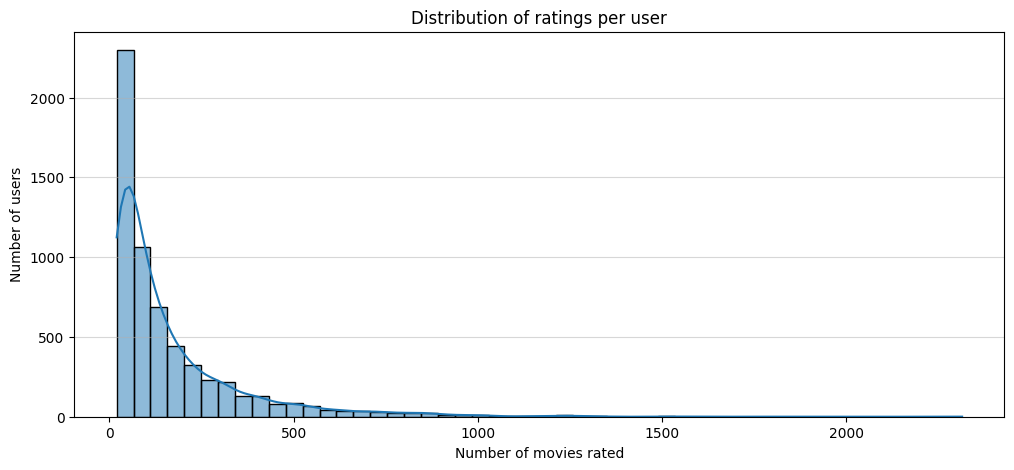

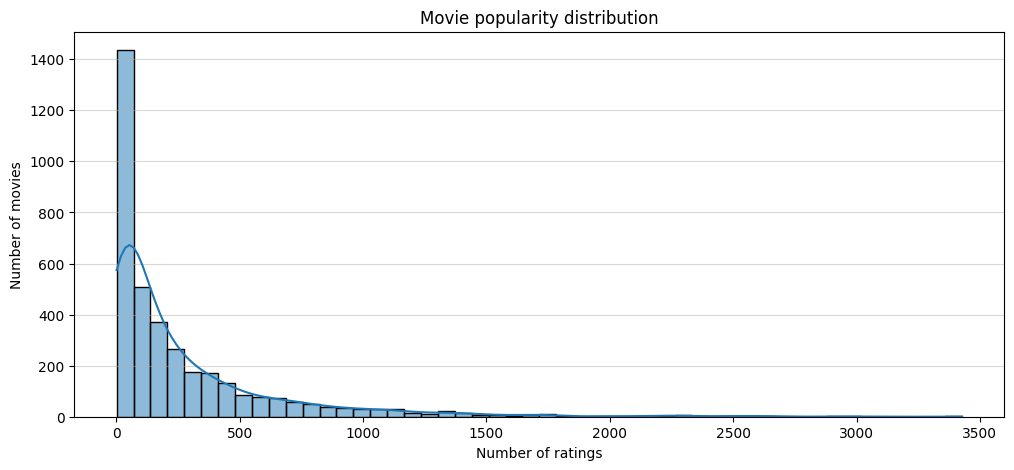

C:\Users\Administrator\AppData\Local\Temp\ipykernel_14000\4082444305.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.index, y=rating_counts.values, palette="viridis")


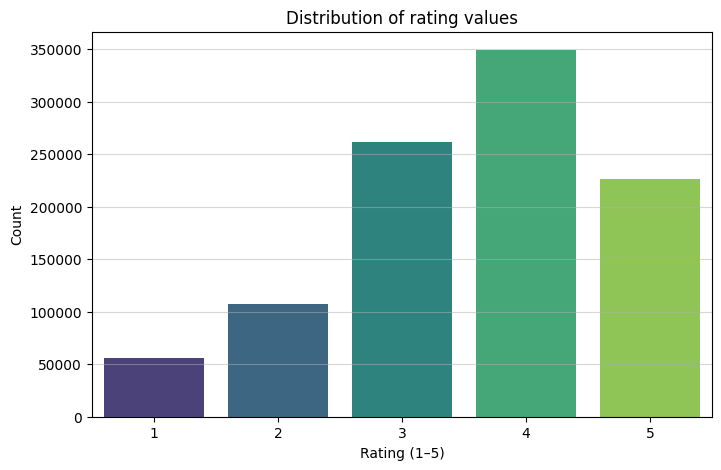

Top 10 movies by number of ratings:
      MovieID  num_ratings                                              Title
2651     2858         3428                             American Beauty (1999)
253       260         2991          Star Wars: Episode IV - A New Hope (1977)
1106     1196         2990  Star Wars: Episode V - The Empire Strikes Back...
1120     1210         2883  Star Wars: Episode VI - Return of the Jedi (1983)
466       480         2672                               Jurassic Park (1993)
1848     2028         2653                         Saving Private Ryan (1998)
575       589         2649                  Terminator 2: Judgment Day (1991)
2374     2571         2590                                 Matrix, The (1999)
1178     1270         2583                          Back to the Future (1985)
579       593         2578                   Silence of the Lambs, The (1991)


In [48]:
# Ratings per user
ratings_per_user = dataset_col.groupby("UserID")["MovieID"].count()
plt.figure(figsize=(12, 5))
sns.histplot(ratings_per_user, bins=50, kde=True)
plt.title("Distribution of ratings per user")
plt.xlabel("Number of movies rated")
plt.ylabel("Number of users")
plt.grid(axis="y", alpha=0.5)
plt.show()

# Ratings per movie
ratings_per_movie = dataset_col.groupby("MovieID")["Rating"].count()
plt.figure(figsize=(12, 5))
sns.histplot(ratings_per_movie, bins=50, kde=True)
plt.title("Movie popularity distribution")
plt.xlabel("Number of ratings")
plt.ylabel("Number of movies")
plt.grid(axis="y", alpha=0.5)
plt.show()

# Rating value distribution
rating_counts = dataset_col["Rating"].value_counts().sort_index()
plt.figure(figsize=(8, 5))
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette="viridis")
plt.title("Distribution of rating values")
plt.xlabel("Rating (1–5)")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.5)
plt.show()

# Top 10 most-rated movies
top10 = (
    pd.merge(ratings_per_movie.reset_index(), movies[["MovieID", "Title"]], on="MovieID")
    .rename(columns={"Rating": "num_ratings"})
    .nlargest(10, "num_ratings")
)
print("Top 10 movies by number of ratings:")
print(top10)

Users: 1447  |  Movies: 3494  |  Sparsity: 95.30%


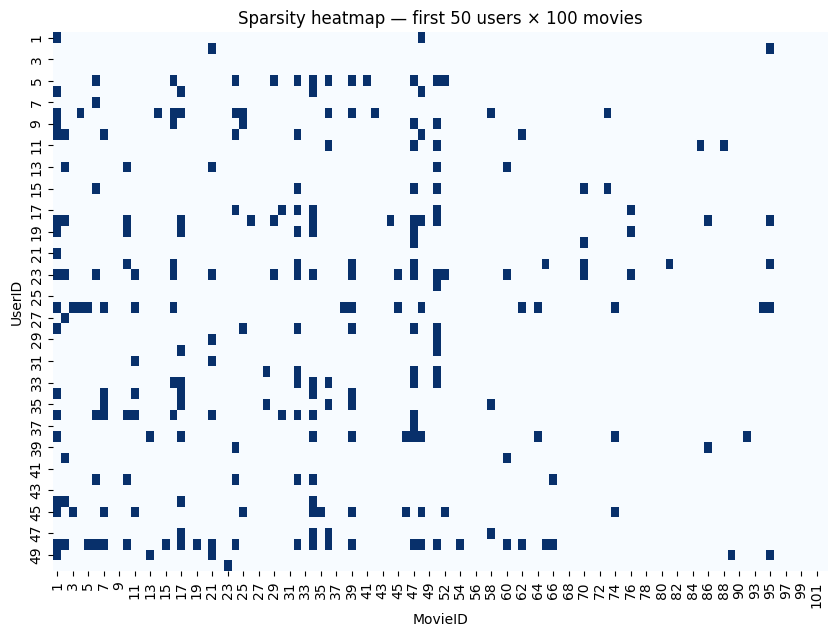

In [5]:
n_users  = dataset_col["UserID"].nunique()
n_movies = dataset_col["MovieID"].nunique()
sparsity = 1 - len(dataset_col) / (n_users * n_movies)
print(f"Users: {n_users}  |  Movies: {n_movies}  |  Sparsity: {sparsity:.2%}")

interaction_matrix = dataset_col.pivot_table(
    index="UserID", columns="MovieID", values="Rating"
)
plt.figure(figsize=(10, 7))
sns.heatmap(interaction_matrix.iloc[:50, :100].isnull(), cbar=False, cmap="Blues_r")
plt.title("Sparsity heatmap — first 50 users × 100 movies")
plt.xlabel("MovieID")
plt.ylabel("UserID")
plt.show()

In [49]:
# encode + split
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

user_encoder  = LabelEncoder()
movie_encoder = LabelEncoder()

dataset_col["user_idx"]  = user_encoder.fit_transform(dataset_col["UserID"])
dataset_col["movie_idx"] = movie_encoder.fit_transform(dataset_col["MovieID"])

train_data, test_data = train_test_split(
    dataset_col, test_size=0.2, random_state=42
)

###
train_data = train_data.copy()
test_data  = test_data.copy()

print("Train:", train_data.shape, "  Test:", test_data.shape)
print("Users:", dataset_col["user_idx"].nunique())
print("Movies:", dataset_col["movie_idx"].nunique())

Train: (800167, 13)   Test: (200042, 13)
Users: 6040
Movies: 3706


In [50]:
from scipy.sparse import csr_matrix

num_users  = dataset_col["user_idx"].nunique()
num_movies = dataset_col["movie_idx"].nunique()

user_item_matrix = csr_matrix(
    (
        train_data["Rating"].astype(np.float32),
        (train_data["user_idx"], train_data["movie_idx"])
    ),
    shape=(num_users, num_movies)
)

print("Matrix shape:", user_item_matrix.shape)
print("Non-zero entries:", user_item_matrix.nnz)


Matrix shape: (6040, 3706)
Non-zero entries: 800167


In [52]:
%pip install implicit


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [53]:
from implicit.als import AlternatingLeastSquares

# tạo confidence matrix
confidence = user_item_matrix.copy().astype(np.float32)

# khởi tạo model
als_model = AlternatingLeastSquares(
    factors=64,
    regularization=0.1,
    iterations=20,
    random_state=42
)

#train
als_model.fit(user_item_matrix)

print("User factors:", als_model.user_factors.shape)
print("Item factors:", als_model.item_factors.shape)

c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\implicit\cpu\als.py:96: RuntimeWarning: OpenBLAS is configured to use 16 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


  0%|          | 0/20 [00:00<?, ?it/s]

User factors: (6040, 64)
Item factors: (3706, 64)


In [54]:
# mapping movie_idx => Title

movie_info = (
    dataset_col[
        ["movie_idx", "MovieID", "Title", "Genres"]
    ]
    .drop_duplicates()
    .sort_values("movie_idx")
)

print(movie_info.shape)

(3706, 4)


In [55]:
movie_info.head()

,movie_idx,MovieID,Title,Genres
40,0,1,Toy Story (1995),Animation|Children's|Comedy
839,1,2,Jumanji (1995),Adventure|Children's|Fantasy
3406,2,3,Grumpier Old Men (1995),Comedy|Romance
583,3,4,Waiting to Exhale (1995),Comedy|Drama
3408,4,5,Father of the Bride Part II (1995),Comedy


In [56]:
from sklearn.metrics.pairwise import cosine_similarity
def recommend_for_user(target_user, n=10):
# user rcm
    user_vector = als_model.user_factors[target_user]

  # similarity giữa user hiện tại và tất cả user
    user_similarity = cosine_similarity(
        user_vector.reshape(1,-1),
        als_model.user_factors
    ).flatten()

  # lấy 10 user giống nhất
    similar_users = (
        np.argsort(user_similarity)[::-1][1:11]
    )

# kiếm phim user A thích rcm user B cùng sở thích chưa xem
    similar_user_movies = train_data[
        train_data["user_idx"].isin(similar_users)
    ]


    liked_movies = similar_user_movies[
        similar_user_movies["Rating"] >= 4
    ]

# xóa phim user đã từng xem
    watched_movies = train_data[
        train_data["user_idx"] == target_user
    ]["movie_idx"].unique()



    candidates = liked_movies[
        ~liked_movies["movie_idx"].isin(
            watched_movies
        )
    ]

#rank
    recommendations = (
        candidates
        .groupby(
            [
                "movie_idx",
                "MovieID",
                "Title",
                "Genres"
            ]
        )
        .size()
        .reset_index(
            name="similar_user_count"
        )
    )


    recommendations = (
        recommendations
        .sort_values(
            "similar_user_count",
            ascending=False
        )
    )


    return recommendations.head(n)

In [57]:
# test
user = 253


print("USER HISTORY")

display(
    dataset_col[
        dataset_col.user_idx == user
    ][
        ["Title","Genres","Rating"]
    ].sort_values("Rating",ascending=False).head(10))


print("\nRECOMMENDATION")


display(recommend_for_user(user,10))

USER HISTORY


,Title,Genres,Rating
37257,"Birds, The (1963)",Horror,5
37276,Remember the Titans (2000),Drama,5
37268,"Wolf Man, The (1941)",Horror,5
37258,Back to the Future (1985),Comedy|Sci-Fi,4
37264,"Thing, The (1982)",Action|Horror|Sci-Fi|Thriller,4
37255,"American Werewolf in London, An (1981)",Horror,4
37254,"Invisible Man, The (1933)",Horror|Sci-Fi,4
37274,"Godfather: Part II, The (1974)",Action|Crime|Drama,4
37272,Alien (1979),Action|Horror|Sci-Fi|Thriller,4
37273,Psycho (1960),Horror|Thriller,4



RECOMMENDATION


,movie_idx,MovieID,Title,Genres,similar_user_count
30,1166,1258,"Shining, The (1980)",Horror,6
53,1802,1982,Halloween (1978),Horror,6
38,1247,1345,Carrie (1976),Horror,4
54,1814,1994,Poltergeist (1982),Horror|Thriller,4
17,907,968,Night of the Living Dead (1968),Horror|Sci-Fi,3
24,1108,1198,Raiders of the Lost Ark (1981),Action|Adventure,3
2,253,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Fantasy|Sci-Fi,3
43,1305,1407,Scream (1996),Horror|Thriller,3
39,1249,1347,"Nightmare on Elm Street, A (1984)",Horror,3
88,2660,2867,Fright Night (1985),Comedy|Horror,3


In [ ]:
def precision_recall_at_k(
    model,
    test_data,
    k=10,
    rating_threshold=4
):

    users = test_data["user_idx"].unique()

    total_precision = 0
    total_recall = 0
    n_users = 0


    for user_idx in users:

        user_test = test_data[
            test_data["user_idx"] == user_idx
        ]


        relevant_movies = set(
            user_test[
                user_test["Rating"] >= rating_threshold
            ]["movie_idx"]
        )


        if len(relevant_movies) == 0:
            continue


        n_users += 1


        recommended_items = model.recommend(
            user_idx,
            user_items=user_item_matrix.getrow(user_idx),
            N=k,
            filter_already_liked_items=True
        )


        recommended_movies = set(
            item[0]
            for item in recommended_items
        )


        hits = len(
            relevant_movies &
            recommended_movies
        )


        total_precision += hits / k

        total_recall += (
            hits /
            len(relevant_movies)
        )


    return (
        total_precision/n_users,
        total_recall/n_users
    )

In [ ]:
precision, recall = precision_recall_at_k(
    als_model,
    test_data,
    k=10,
    rating_threshold=4
)

print(f"Precision@10: {precision:.4f}")
print(f"Recall@10: {recall:.4f}")

Precision@10: 0.0413
Recall@10: 0.0371


#Hybrid


In [58]:
user_id = 20

In [59]:
# load mapping file đã làm ở mục bert score
mapping_bridge = pd.read_csv("movie_mapping.csv")

mapping_bridge["movie_id"] = mapping_bridge["movie_id"].astype(int)
mapping_bridge["id"] = mapping_bridge["id"].astype(str)

df_final["id"] = df_final["id"].astype(str)

In [60]:
# MovieLens movie_id -> TMDB id
movieid_to_tmdb = dict(
    zip(
        mapping_bridge["movie_id"],
        mapping_bridge["id"]))

In [61]:
# TMDB id -> df_final index
tmdb_to_dfidx = dict(
    zip(
        df_final["id"],
        df_final.index))

In [62]:
# ALS index -> MovieLens movie_id
alsidx_to_movieid = dict(
    zip(movie_encoder.transform(movie_encoder.classes_),
        movie_encoder.classes_))

In [63]:
# Lấy seed movie (phim cuối cùng user xem)
user_train_history = df_ratings_train[
    df_ratings_train["user_id"] == user_id
]

if user_train_history.empty:
    raise ValueError(
        f"User {user_id} has no training history."
    )

sample_seed_movie = str(
    user_train_history.iloc[-1]["movie_id"]
).strip()

print("User ID:", user_id)
print("Seed Movie ID:", sample_seed_movie)

User ID: 20
Seed Movie ID: 157


In [64]:
from sentence_transformers import util
from sklearn.preprocessing import MinMaxScaler

num_movies = len(df_final)

df_final_bert = df_final.copy()
df_final_bert["id"] = (df_final_bert["id"].astype(str).str.strip())

matched_indices = df_final_bert[df_final_bert["id"] == sample_seed_movie].index

if len(matched_indices) == 0:
    raise ValueError(
        f"Seed movie {sample_seed_movie} not found in df_final.")

# Cosine similarity với toàn bộ kho phim
seed_idx = matched_indices[0]
target_embedding = movie_embeddings[seed_idx]

bert_scores = util.cos_sim(
    target_embedding,
    movie_embeddings
)[0].cpu().numpy()

# Normalize BERT
bert_scores_scaled = MinMaxScaler().fit_transform(
    bert_scores.reshape(-1, 1)
).flatten()

In [65]:
als_scores_ordered = np.zeros(num_movies)

try:
    user_idx = user_encoder.transform([user_id])[0]

except ValueError:
    raise ValueError(
        f"UserID {user_id} not found."
    )

user_items = user_item_matrix[user_idx]

ids, als_scores_raw = als_model.recommend(
    userid=user_idx,
    user_items=user_items,
    N=len(movie_encoder.classes_),
    filter_already_liked_items=False
)

for als_idx, score in zip(ids, als_scores_raw):

    # ALS index → MovieLens movie_id
    movie_id = alsidx_to_movieid.get(als_idx)

    if movie_id is None:
        continue

    # MovieLens movie_id → TMDB id
    tmdb_id = movieid_to_tmdb.get(movie_id)

    if tmdb_id is None:
        continue

    # TMDB id → df_final index
    df_idx = tmdb_to_dfidx.get(str(tmdb_id))

    if df_idx is None:
        continue

    als_scores_ordered[df_idx] = score

# Normalize ALS
als_scores_scaled = MinMaxScaler().fit_transform(
    als_scores_ordered.reshape(-1, 1)
).flatten()

In [66]:
from scipy.stats import rankdata

# BERT -> Percentile Rank
bert_rank = rankdata(
    bert_scores_scaled,
    method="average"
)

bert_percentile = (
    bert_rank / len(bert_rank)
)

# ALS -> Percentile Rank
als_rank = rankdata(
    als_scores_scaled,
    method="average"
)

als_percentile = (
    als_rank / len(als_rank)
)

# Fusion
alpha = 0.5

hybrid_scores = (
    alpha * bert_percentile
    + (1 - alpha) * als_percentile)

In [67]:
# loại fim user đã xem
seen_movies = (
    df_ratings_cleaned[
        df_ratings_cleaned["user_id"] == user_id
    ]["movie_id"]
    .astype(int)
    .unique())

for movie_id in seen_movies:

    tmdb_id = movieid_to_tmdb.get(movie_id)

    if tmdb_id is None:
        continue

    df_idx = tmdb_to_dfidx.get(str(tmdb_id))

    if df_idx is not None:
        hybrid_scores[df_idx] = -1

In [68]:
# top k
TOP_K = 10

top_indices = np.argsort(
    hybrid_scores
)[::-1][:TOP_K]

recommendations = (
    df_final.iloc[top_indices][
        ["id", "title"]
    ]
    .copy()
)

recommendations["Hybrid Score"] = (
    hybrid_scores[top_indices]
)

recommendations.reset_index(
    drop=True,
    inplace=True
)

print("===== HYBRID RECOMMENDATIONS =====")
print(f"User ID: {user_id}")
print(f"Seed Movie ID: {sample_seed_movie}")

recommendations

===== HYBRID RECOMMENDATIONS =====
User ID: 20
Seed Movie ID: 157


,id,title,Hybrid Score
0,199,Star Trek: First Contact,0.999783
1,168,Star Trek IV: The Voyage Home,0.999783
2,174,Star Trek VI: The Undiscovered Country,0.999627
3,157,Star Trek III: The Search for Spock,0.999591
4,193,Star Trek: Generations,0.999519
5,152,Star Trek: The Motion Picture,0.999494
6,200,Star Trek: Insurrection,0.999434
7,172,Star Trek V: The Final Frontier,0.999302
8,926,Galaxy Quest,0.997785
9,698,Moonraker,0.997641
